In [ ]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 54.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 45.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 9.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=8d9808ac5ba6e20a1766597db642d81e4b857f2f0b442ee6d1e88a52909ecef8
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


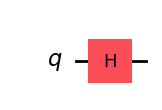

In [ ]:

# Create a circuit with one qubit
circuit = QuantumCircuit(1)

# Add a Hadamard (H) gate on qubit 0, to create a superposition
circuit.h(0)

# Draw the circuit diagram. Delete "mpl" to get a text diagram.
circuit.draw("mpl")

In [ ]:
# Now simulate the circuit by calculating the effect on state vectors.
# Set the initial state of the simulator to |0>
# The state vector has two coefficients, both 0
state = Statevector.from_int(0, 2)

# Apply the circuit to the state
state = state.evolve(circuit)

# Display using latex. This requires the pylatexenc module.
# Omit "latex" to get a numerical (not algebraic) view of the state vector.
state.draw("latex")

<IPython.core.display.Latex object>

In [ ]:
# A different way of dislaying the state, again using latex
from qiskit.visualization import array_to_latex

array_to_latex(state)

<IPython.core.display.Latex object>

In [ ]:
# The whole circuit is a unitary operator, which we can display.

U = Operator(circuit)
array_to_latex(U)

<IPython.core.display.Latex object>

In [ ]:
# Or less beautifully:
U.data
# The format is a little bit odd. 0.j means the imaginary part is 0
# 0 is being displayed with a decimal point but no trailing 0
# j is used for the square root of -1, instead of i

array([[ 0.70710678+0.j,  0.70710678+0.j],
       [ 0.70710678+0.j, -0.70710678+0.j]])

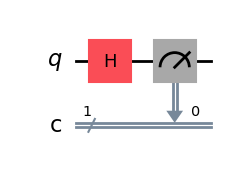

In [ ]:
# Now reconstruct the circuit and add a measurement
# The second parameter of QuantumCircuit is the number of classical bits
circuit = QuantumCircuit(1,1)
circuit.h(0)

# The first list is the qubits to measure,
# the second list is the classical bits where the results go
circuit.measure([0],[0])
circuit.draw("mpl")

In [ ]:
# We will need to transpile the circuit into QASM instructions for the back end

# Use BasicSimulator
backend = BasicSimulator()

# Compile / transpile
qc_compiled = transpile(circuit, backend)

# Run the circuit on the simulator.
# We've set the number of repeats of the circuit
# to be 1024, which is the default.
# The qubits start in state |0>
job_sim = backend.run(qc_compiled, shots=1024)

# Grab the results from the job (this doesn't produce any output).
result_sim = job_sim.result()

In [ ]:
# The simplest way to see the results of the simulation
counts = result_sim.get_counts(qc_compiled)
print(counts)

# The results are not exactly half 0 and half 1, but should be close.
# There will be different results each time the previous cell is run.

{'1': 505, '0': 519}


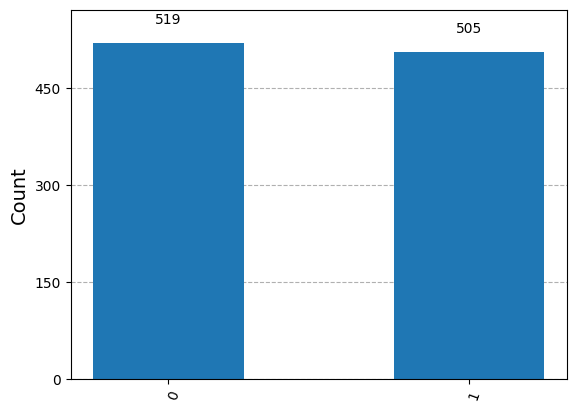

In [ ]:
# We can also produce a graph

plot_histogram(counts)

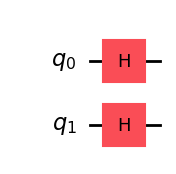

In [ ]:
# Now let's move on to two qubits.
# Apply H to both qubits and see what we get.

circuit = QuantumCircuit(2)
circuit.h(0)
circuit.h(1)

circuit.draw("mpl")

In [ ]:
state = Statevector.from_int(0, 4) # 4 is the number of basis states on 2 qubits
state = state.evolve(circuit)
state.draw("latex")

<IPython.core.display.Latex object>

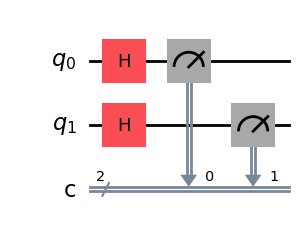

In [ ]:
# Now measurement. This time we construct the measurement part
# of the circuit separately and then combine it with the first circuit.

# A new circuit with 2 qubits and 2 classical bits
meas = QuantumCircuit(2, 2)

# Map the quantum measurement to the classical bits
meas.measure(range(2), range(2))

# The Qiskit circuit object supports composition.
# Here the meas has to be first and front=True (putting it before)
# as compose must put a smaller circuit into a larger one.
qc = meas.compose(circuit, range(2), front=True)

qc.draw("mpl")

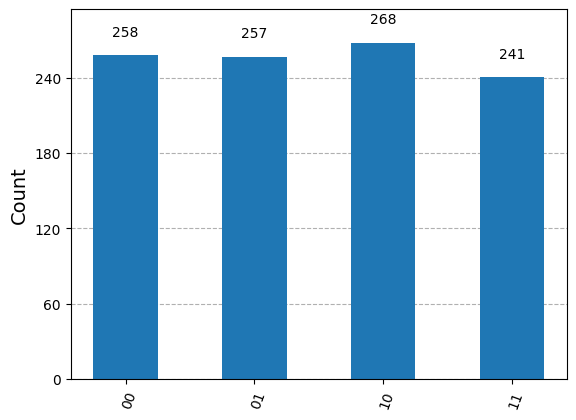

In [ ]:
# Simulate again, using the same back end
qc_compiled = transpile(qc, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
plot_histogram(counts)

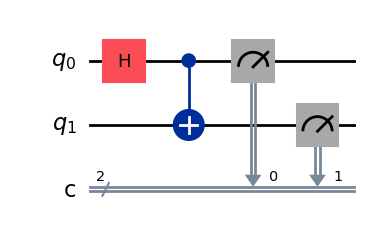

In [ ]:
# Now for some entanglement.
# Construct a Bell state and measure both qubits to see that
# both measurements give the same result.

circuit = QuantumCircuit(2,2)
circuit.h(0)
circuit.cx(0,1) # cx means CNOT because it's a controlled version of x (negation)
circuit.measure(range(2),range(2))
circuit.draw("mpl")

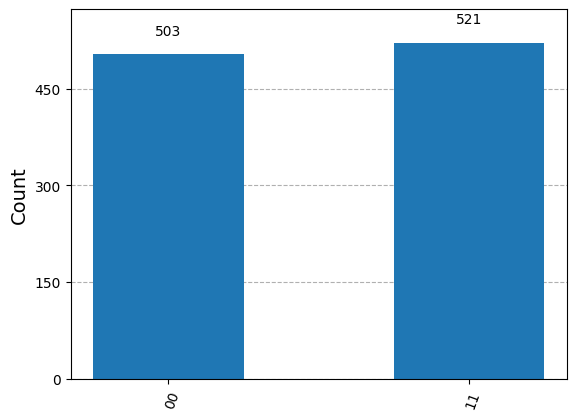

In [ ]:
qc_compiled = transpile(circuit, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
plot_histogram(counts)

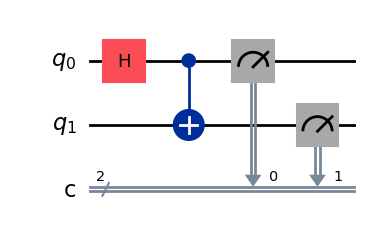

In [ ]:
# EXERCISE

# Make a copy here of the circuit that creates the Bell state 1/sqrt(2) ( |00> + |11> ).
circuit = QuantumCircuit(2,2)
circuit.h(0)
circuit.cx(0,1)
circuit.measure(range(2),range(2))
circuit.draw("mpl")

# You will need to use X and Z gates. Check that your circuit is correct by displaying the state vector in each case.

In [ ]:
# Check the state vector (no measurement needed here)
circuit_no_meas = QuantumCircuit(2)
circuit_no_meas.h(0)
circuit_no_meas.cx(0, 1)

state = Statevector.from_int(0, 4)
state = state.evolve(circuit_no_meas)
state.draw("latex")

<IPython.core.display.Latex object>

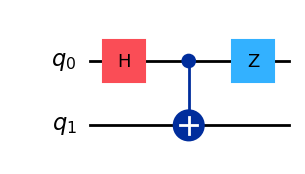

In [ ]:
# Modify it to create the other Bell states:
# 2. 1/sqrt(2) ( |00> - |11> )
# 3. 1/sqrt(2) ( |01> + |10> )
# 4. 1/sqrt(2) ( |01> - |10> )

# Bell State 2 — add Z on qubit 0
circuit2 = QuantumCircuit(2)
circuit2.h(0)
circuit2.cx(0, 1)
circuit2.z(0)  # flips the sign of |11⟩ to -|11⟩

circuit2.draw("mpl")

In [ ]:
# Check state
state = Statevector.from_int(0, 4)
state = state.evolve(circuit2)
state.draw("latex")

<IPython.core.display.Latex object>

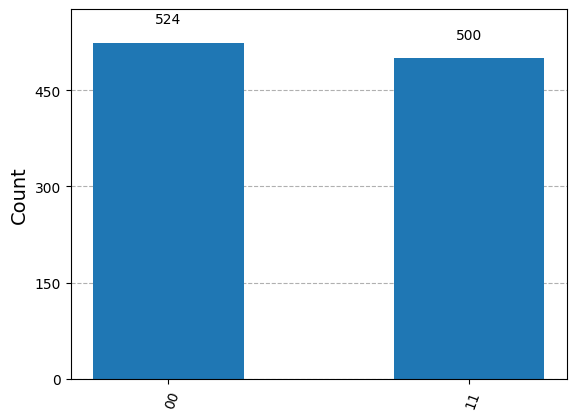

In [ ]:
# For each of the Bell states, repeat the simulation with measurements and check that the results are as expected.
circuit2_meas = QuantumCircuit(2, 2)
circuit2_meas.h(0)
circuit2_meas.cx(0, 1)
circuit2_meas.z(0)
circuit2_meas.measure(range(2), range(2))

qc_compiled = transpile(circuit2_meas, backend)
job_sim = backend.run(qc_compiled, shots=1024)
counts = job_sim.result().get_counts(qc_compiled)
plot_histogram(counts)

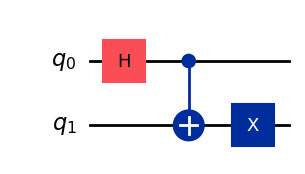

In [ ]:
# Bell State 3 — add X on qubit 1
circuit3 = QuantumCircuit(2)
circuit3.h(0)
circuit3.cx(0, 1)
circuit3.x(1)   # flips qubit 1: |0⟩↔|1⟩
circuit3.draw("mpl")

In [ ]:
state = Statevector.from_int(0, 4)
state = state.evolve(circuit3)
state.draw("latex")

<IPython.core.display.Latex object>

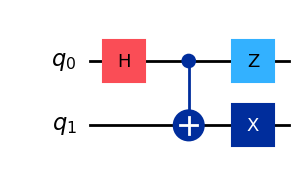

In [ ]:
# Bell State 4 — add X on qubit 1 + Z on qubit 0
circuit4 = QuantumCircuit(2)
circuit4.h(0)
circuit4.cx(0, 1)
circuit4.x(1)
circuit4.z(0)
circuit4.draw("mpl")


In [ ]:
state = Statevector.from_int(0, 4)
state = state.evolve(circuit4)
state.draw("latex")

<IPython.core.display.Latex object>

In [ ]:
# EXERCISE

# The GHZ state on any number of qubits has the form  1/sqrt(2) ( |00...0> + |11...1> )

# The Bell state 1/sqrt(2) ( |00> + |11> ) is the case for two qubits.

# Write code to construct a circuit that produces a GHZ state for any given number of qubits.

# Try simulating the circuit, with measurements. How many qubits can the simulator handle in a reasonable time?

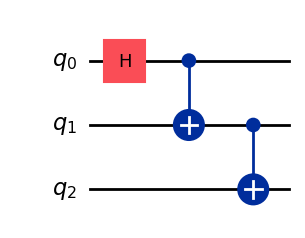

In [ ]:
def ghz_circuit(n):
    circuit = QuantumCircuit(n)
    circuit.h(0)                        # superposition on first qubit
    for i in range(n - 1):              # chain CNOTs
        circuit.cx(i, i + 1)
    return circuit

# Test with 3 qubits
ghz_circuit(3).draw("mpl")

In [ ]:
# Check State Vector
n = 3
qc = ghz_circuit(n)

state = Statevector.from_int(0, 2**n)
state = state.evolve(qc)
state.draw("latex")

<IPython.core.display.Latex object>

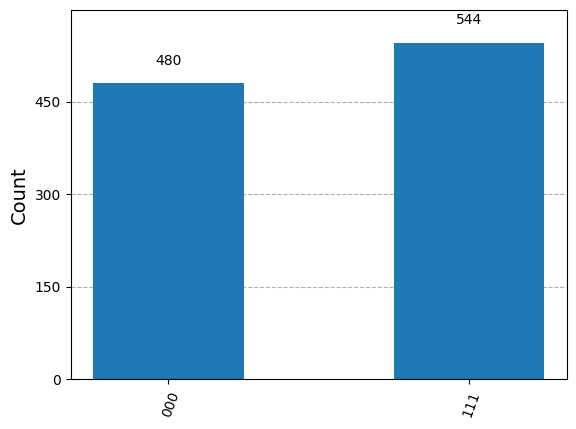

In [ ]:
def ghz_with_measurement(n):
    circuit = QuantumCircuit(n, n)
    circuit.h(0)
    for i in range(n - 1):
        circuit.cx(i, i + 1)
    circuit.measure(range(n), range(n))
    return circuit

# Run it
n = 3
qc = ghz_with_measurement(n)
qc_compiled = transpile(qc, backend)
counts = backend.run(qc_compiled, shots=1024).result().get_counts(qc_compiled)
plot_histogram(counts)


In [ ]:
import time

for n in [5, 10, 15, 20, 24, 25, 30]:
    if n > 24:
        print(f"n={n}: exceeds simulator limit (max 24)")
        continue

    qc = ghz_with_measurement(n)
    qc_compiled = transpile(qc, backend)

    start = time.time()
    counts = backend.run(qc_compiled, shots=1024).result().get_counts(qc_compiled)
    elapsed = time.time() - start

    print(f"n={n}: {elapsed:.2f}s")


n=5: 0.01s
n=10: 0.01s
n=15: 0.03s
n=20: 1.13s
n=24: 17.14s
n=25: exceeds simulator limit (max 24)
n=30: exceeds simulator limit (max 24)
